### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
#import libraries for analysis
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [37]:
#load dataset to dataframe
data = pd.read_csv('/workspaces/UC5.1-CouponAnalysis/Data/coupons.csv')

In [38]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [39]:
#review dataset
data.isnull().sum()


destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

In [40]:
#car column has 12576 out of 12684 populated so drop column
data = data.drop(columns='car')

#columns relating to count of the person's frequency of visits have significant blank values; for consistency, will replace with never
freq_visit_cols = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']
data[freq_visit_cols] = data[freq_visit_cols].fillna('never')

4. What proportion of the total observations chose to accept the coupon?



In [41]:
#overall acceptance
tot_accept_percent = round ( ( data['Y'].sum() / data['Y'].count() ) * 100 , 2)
print(f"Overall acceptance rate is {tot_accept_percent} %")

#acceptance by coupon type
coup_accept_percent = round ( ( data.loc[data['Y']==1].groupby(data['coupon'])['Y'].sum() / data['Y'].groupby(data['coupon']).count() ) * 100 , 2 )
print("\nThe acceptance rate (%) by coupon type is")
print(coup_accept_percent.to_string())

#acceptance by gender
gen_accept_percent = round ( ( data.loc[data['Y']==1].groupby(data['gender'])['Y'].sum() / data['Y'].groupby(data['gender']).count() ) * 100 , 2 )
print("\nThe acceptance rate (%) by gender is")
print(gen_accept_percent.to_string())

#acceptance by passanger
pas_accept_percent = round ( ( data.loc[data['Y']==1].groupby(data['passanger'])['Y'].sum() / data['Y'].groupby(data['passanger']).count() ) * 100 , 2 )
print("\nThe acceptance rate (%) by passanger is")
print(pas_accept_percent.to_string())

#acceptance by weather
weat_accept_percent = round ( ( data.loc[data['Y']==1].groupby(data['weather'])['Y'].sum() / data['Y'].groupby(data['weather']).count() ) * 100 , 2 )
print("\nThe acceptance rate (%) by weather is")
print(weat_accept_percent.to_string())

Overall acceptance rate is 56.84 %

The acceptance rate (%) by coupon type is
coupon
Bar                      41.00
Carry out & Take away    73.55
Coffee House             49.92
Restaurant(20-50)        44.10
Restaurant(<20)          70.71

The acceptance rate (%) by gender is
gender
Female    54.72
Male      59.08

The acceptance rate (%) by passanger is
passanger
Alone        52.58
Friend(s)    67.34
Kid(s)       50.50
Partner      59.53

The acceptance rate (%) by weather is
weather
Rainy    46.28
Snowy    47.05
Sunny    59.48


5. Use a bar plot to visualize the `coupon` column.

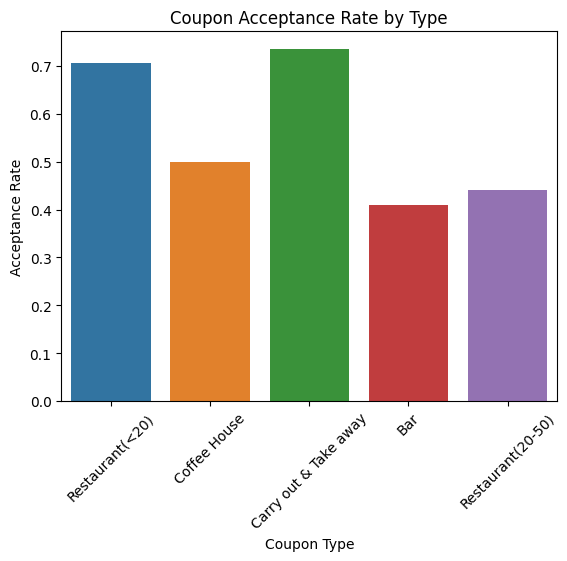

In [42]:
#bar chart to visualize coupon type acceptance rate
sns.barplot(data=data,x='coupon',y='Y',hue='coupon',errorbar=None)
plt.title('Coupon Acceptance Rate by Type')
plt.xlabel('Coupon Type')
plt.ylabel('Acceptance Rate')
plt.xticks(rotation=45)
plt.savefig('/workspaces/UC5.1-CouponAnalysis/Images/acceptance_by_type.png')
plt.show()

6. Use a histogram to visualize the temperature column.

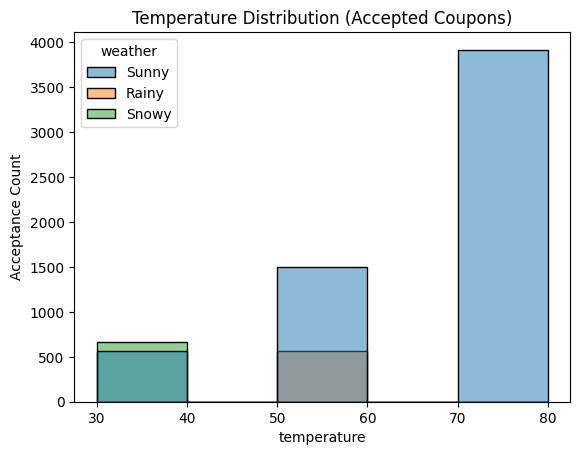

In [43]:
#histogram to visualize temperature acceptance counts, with weather indicating further detail
sns.histplot(data=data[data['Y'] == 1],x='temperature',binwidth=10,hue='weather')
plt.title('Temperature Distribution (Accepted Coupons)')
plt.ylabel('Acceptance Count')
plt.savefig('/workspaces/UC5.1-CouponAnalysis/Images/temperature_dist_acceptance.png')
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [44]:
#new dataframe for bar coupons only
bar_data = data.loc[data['coupon']=='Bar']
bar_data

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12663,No Urgent Place,Friend(s),Sunny,80,10PM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12664,No Urgent Place,Friend(s),Sunny,55,10PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12667,No Urgent Place,Alone,Rainy,55,10AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12670,No Urgent Place,Partner,Rainy,55,6PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0


2. What proportion of bar coupons were accepted?


In [45]:
#bar acceptances
bar_accept_rate = round(bar_data['Y'].mean() * 100 , 2 )
print("The acceptance rate for bar coupons was",bar_accept_rate,"%")

The acceptance rate for bar coupons was 41.0 %


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [46]:
#comparison of people based on how often they visit bars each month

few_visits =['never','less1','1~3'] #all results that indicate person goes to bar less than 3 or less times a month 
more_visits = ['4~8','gt8'] #all results that indicate person goes to bar more than 3 times a month 

accept_few = round( bar_data.loc[bar_data['Bar'].isin(few_visits),'Y'].mean() * 100,2) #acceptance rate of those who go to bar 3 or fewer times a month
accept_more = round( bar_data.loc[bar_data['Bar'].isin(more_visits),'Y'].mean() *100,2) #acceptance rate of those who go to bar >3 times a month

print("The acceptance rate for those who visited bars three or fewer times a month was",accept_few,"%")
print("The acceptance rate for those who visited bars more than three times a month was",accept_more,"% - More than double!")

The acceptance rate for those who visited bars three or fewer times a month was 37.07 %
The acceptance rate for those who visited bars more than three times a month was 76.88 % - More than double!


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [47]:
visit_m1 = ['1~3','4~8','gt8'] #subset of bar visits >=1

bar_data['age'] = bar_data['age'].replace('50plus',50).replace('below21',20).pipe(pd.to_numeric, errors='coerce') #age column has mix of ints and str so converting the strings and then changing to numerical

bar_data_m1 = bar_data.loc[bar_data['Bar'].isin(visit_m1)] #creating dataframe for drivers who visit bar 1 or more times a month
accept_m1 = round( bar_data_m1['Y'].mean() * 100, 2) #calculating acceptance rates for drivers who visit bar 1 or more times a mont

accept_m1_m25 = round( bar_data_m1.loc[bar_data_m1['age'] > 25,'Y'].mean() * 100, 2) #check acceptance rate for drivers aged >25  
accept_m1_l25 = round( bar_data_m1.loc[bar_data_m1['age'] < 26,'Y'].mean() * 100, 2) #check acceptance rate for drivers aged 25 or less)  

print("The acceptance rate of drivers who visit bars more than once a month and are over 25 was",accept_m1_m25,"%")
print("Whereas it was",accept_m1,"%","for the drivers who visit bars more than once in general")
print("The drivers aged 25 or under in this group had an acceptance rate of",accept_m1_l25,"%")
print("These acceptance rates are very similar so it would suggest the age is not a significant factor in acceptance if a driver visits bars more than once a month")

The acceptance rate of drivers who visit bars more than once a month and are over 25 was 69.52 %
Whereas it was 68.79 % for the drivers who visit bars more than once in general
The drivers aged 25 or under in this group had an acceptance rate of 67.05 %
These acceptance rates are very similar so it would suggest the age is not a significant factor in acceptance if a driver visits bars more than once a month


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [48]:
#check values from passanger column
passangers = bar_data['passanger'].unique()
passangers

<StringArray>
['Kid(s)', 'Alone', 'Friend(s)', 'Partner']
Length: 4, dtype: str

In [49]:
#check values from occupation column
occupations = bar_data['occupation'].unique()
occupations

<StringArray>
[                               'Unemployed',
                'Architecture & Engineering',
                                   'Student',
                'Education&Training&Library',
                        'Healthcare Support',
      'Healthcare Practitioners & Technical',
                           'Sales & Related',
                                'Management',
  'Arts Design Entertainment Sports & Media',
                   'Computer & Mathematical',
              'Life Physical Social Science',
                   'Personal Care & Service',
               'Community & Social Services',
           'Office & Administrative Support',
                 'Construction & Extraction',
                                     'Legal',
                                   'Retired',
         'Installation Maintenance & Repair',
          'Transportation & Material Moving',
                      'Business & Financial',
                        'Protective Service',
        'Food Prepar

In [50]:
not_kids = ['Alone','Friend(s)','Partner'] #list of passangers who are not kids
x_jobs = ['Farming Fishing & Forestry'] #occupation to rule out

#create new dataframe for bar data where driver visits bar once or more times a month and does not have kids passangers
bar_data_m1_nk = bar_data_m1.loc[bar_data_m1['passanger'].isin(not_kids)]

#acceptance rate for drivers who visit bar once or more times a month and does not have kids passangers, and do not work in farming, fishing & forestry
accept_nk_xj = round( bar_data_m1_nk.loc[~bar_data_m1_nk['occupation'].isin(x_jobs),'Y'].mean() * 100, 2) 

#acceptance rate for drivers who visit bar once or more times a month and do have kids passangers
accept_k = round( bar_data_m1.loc[~bar_data_m1['passanger'].isin(not_kids),'Y'].mean() * 100, 2)

print("The acceptance rate for drivers who visit bar once or more times a month and do not have kids passangers, and do not work in farming, fishing & forestry was",accept_nk_xj,"%")
print("The acceptance rate for drivers who visit bar once or more times a month and do have kids passangers was",accept_k,"%")
print("This suggests the presance of kids as passangers significantly impacts whether the driver accepts bar coupons")


The acceptance rate for drivers who visit bar once or more times a month and do not have kids passangers, and do not work in farming, fishing & forestry was 71.32 %
The acceptance rate for drivers who visit bar once or more times a month and do have kids passangers was 37.78 %
This suggests the presance of kids as passangers significantly impacts whether the driver accepts bar coupons


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [51]:
#check income values
income = bar_data['income'].unique()
income

<StringArray>
[ '$37500 - $49999',  '$62500 - $74999',  '$12500 - $24999',
  '$75000 - $87499',  '$50000 - $62499',  '$25000 - $37499',
  '$100000 or More',  '$87500 - $99999', 'Less than $12500']
Length: 9, dtype: str

In [52]:
#set incomes for less than 50K
incomel50 = ['$37500 - $49999',  '$12500 - $24999','$25000 - $37499', 'Less than $12500']

#new dataframe for income bar coupon records where drivers income is less than 50k
bar_data_l50 = bar_data.loc[bar_data['income'].isin(incomel50)]

In [53]:
accept_m1_nk_nw = round( bar_data_m1_nk.loc[bar_data_m1_nk['maritalStatus']!="Widowed",'Y'].mean() * 100, 2) 
accept_m1_l30 = round( bar_data_m1.loc[bar_data_m1['age'] < 30,'Y'].mean() * 100, 2)
accept_cr4_l50 = round ( bar_data_l50.loc[bar_data_l50['RestaurantLessThan20'].isin(more_visits),'Y'].mean() * 100, 2)

print("The acceptance rate for drivers who visit bar once or more times a month and do not have kids passangers, and are not widowed was",accept_m1_nk_nw,"%")
print("The acceptance rate for drivers who visit bar once or more times a month and are under 30 years old was",accept_m1_l30,"%")
print("The acceptance rate for drivers who go to cheap restaurants more than 4 times a month and have income less than 50K was",accept_cr4_l50,"%")


The acceptance rate for drivers who visit bar once or more times a month and do not have kids passangers, and are not widowed was 71.32 %
The acceptance rate for drivers who visit bar once or more times a month and are under 30 years old was 72.17 %
The acceptance rate for drivers who go to cheap restaurants more than 4 times a month and have income less than 50K was 45.35 %


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

The analysis indicates that bar coupon acceptance depends on driver's passengers. Passangers without kids are much more likely to accept bar coupons than those that are with kids. Additionally, the driver's income also has some impact; drivers with less income are less likely to accept.